# 8. Conversational dynamics

A transcript tells you what was said. The **timing** tells you how the
conversation went: who talks longest, how fast the exchange is, where people
overlap, and how any of that drifts across an hour.

SPoRC stores per-turn start/end times, and `build_indexes.py` precomputes
per-turn and per-episode metrics on top of them — so much of this is a lookup
rather than a computation.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))     # prefer the source tree
sys.path.insert(0, os.path.dirname(os.path.abspath("_viz.py")))

import sporc
if sporc.__version__ < "1.0":
    raise RuntimeError(
        f"This notebook needs sporc >= 1.0 but imported {sporc.__version__} from "
        f"{os.path.dirname(sporc.__file__)}.\n"
        "PyPI's latest release is 0.2.0, which has a different API, so "
        "`pip install sporc` gets you the wrong one. Install this checkout:\n"
        "    pip install -e /path/to/sporc"
    )

from _viz import apply_style, finish, PALETTE, INK, INK_SECONDARY, INK_MUTED
apply_style()
print("sporc", sporc.__version__, "from", os.path.dirname(sporc.__file__))


sporc 1.0.0 from /home/jurgens/projects/sporc/sporc


In [2]:
from sporc import SPORCDataset

# Built by scripts/make_subset.py; see examples/notebooks/README.md.
SUBSET = os.path.abspath("../../subsets/tutorial")
sporc = SPORCDataset(parquet_dir=SUBSET)
print(sporc)


INFO:sporc.dataset:Initializing Parquet backend from /home/jurgens/projects/sporc/subsets/tutorial


INFO:sporc.parquet_backend:Loading indexes from cache /home/jurgens/projects/sporc/subsets/tutorial/metadata/_index_cache.pkl


INFO:sporc.parquet_backend:ParquetBackend loaded from cache in 0.06s  (512 podcasts, 2,428 episodes)


SPORCDataset(parquet, 512 podcasts, 2428 episodes)


## 8.1 Precomputed metrics

`filter_episodes_by_metrics()` reads `episode_metrics.parquet` and touches no
partitions, so you can narrow to the episodes you want *before* paying to load
them. Note that the metrics table only covers diarized episodes — filtering on it
never wastes a fetch on an episode without turns.


In [3]:
import pandas as pd

hits = sporc.filter_episodes_by_metrics(min_turn_count=40, limit=500)
print(f"episodes with >=40 turns: {len(hits)}")
if hits:
    m = pd.DataFrame(hits)
    print("\ncolumns:", list(m.columns))
    cols = [c for c in ["total_turn_count", "total_word_count",
                        "avg_turn_duration", "avg_words_per_second",
                        "avg_gap_duration", "discourse_marker_rate"]
            if c in m.columns]
    print()
    print(m[cols].describe().round(2).to_string())


INFO:sporc.parquet_backend:Loading episode metrics from /home/jurgens/projects/sporc/subsets/tutorial/metadata/episode_metrics.parquet


episodes with >=40 turns: 500

columns: ['episode_id', 'podcast_id', 'total_word_count', 'total_turn_count', 'unique_speaker_count', 'avg_turn_duration', 'median_turn_duration', 'avg_words_per_second', 'host_word_count', 'guest_word_count', 'host_turn_proportion', 'host_word_proportion', 'avg_gap_duration', 'total_overlap_duration', 'discourse_marker_count', 'discourse_marker_rate', 'speaking_rate_host', 'speaking_rate_guest']

       total_turn_count  total_word_count  avg_turn_duration  avg_words_per_second  avg_gap_duration  discourse_marker_rate
count            500.00            500.00             500.00                500.00            500.00                 500.00
mean             305.37           8314.49              19.71                  2.84              1.77                  38.99
std              524.79           5337.09              14.60                  0.36             14.49                  16.82
min               40.00            868.00               2.23            

> **A caveat on one column.** `unique_speaker_count` in this table is not what it
> says: `build_indexes.py` computes it from `turn_count` as a proxy, so it equals
> the turn count rather than a speaker count. Use `num_main_speakers` from the
> episode catalog instead.

## 8.2 Talk time and turn count

Two ways to ask "who dominated?": count turns, or sum seconds. They disagree
whenever one speaker gives long answers and the other asks short questions —
i.e. in every interview.


In [4]:
from collections import Counter

eps = [e for e in sporc.iterate_episodes() if e.has_turn_data]
eps = [e for e in eps if e.turn_count >= 40 and e.num_main_speakers >= 2]
print(f"multi-speaker episodes with >=40 turns: {len(eps)}")

ep = max(eps, key=lambda e: e.turn_count)
turns = ep.turns
print(f"\nexample: {ep.title[:56]!r}")
print(f"  {ep.podcast_title[:50]}  ·  {ep.duration_minutes:.0f} min  ·  {len(turns)} turns")

by_turns = Counter()
by_time = Counter()
for t in turns:
    sp = t.primary_speaker
    by_turns[sp] += 1
    by_time[sp] += t.duration

print()
for sp in sorted(by_time, key=by_time.get, reverse=True):
    print(f"  {sp:14s} {by_turns[sp]:4d} turns  {by_time[sp]/60:6.1f} min  "
          f"({by_time[sp]/sum(by_time.values()):5.1%} of talk time)")


INFO:sporc.parquet_backend:Loading episode DataFrame from feather cache


INFO:sporc.parquet_backend:Loading podcast DataFrame from feather cache


multi-speaker episodes with >=40 turns: 1218

example: 'May 6th 2020'
  The Billy Madison Show Podcast  ·  175 min  ·  3609 turns

  SPEAKER_08     1556 turns    81.7 min  (46.7% of talk time)
  SPEAKER_09     1148 turns    53.8 min  (30.7% of talk time)
  SPEAKER_15       62 turns     4.7 min  ( 2.7% of talk time)
  SPEAKER_05      133 turns     3.8 min  ( 2.1% of talk time)
  SPEAKER_14       69 turns     3.6 min  ( 2.1% of talk time)
  SPEAKER_27       35 turns     2.9 min  ( 1.7% of talk time)
  SPEAKER_06       61 turns     2.4 min  ( 1.3% of talk time)
  SPEAKER_25       64 turns     2.3 min  ( 1.3% of talk time)
  SPEAKER_17       81 turns     1.7 min  ( 1.0% of talk time)
  SPEAKER_04       72 turns     1.7 min  ( 1.0% of talk time)
  SPEAKER_21       24 turns     1.4 min  ( 0.8% of talk time)
  SPEAKER_35       14 turns     1.1 min  ( 0.6% of talk time)
  SPEAKER_02       17 turns     0.9 min  ( 0.5% of talk time)
  SPEAKER_12       13 turns     0.9 min  ( 0.5% of talk time)
 

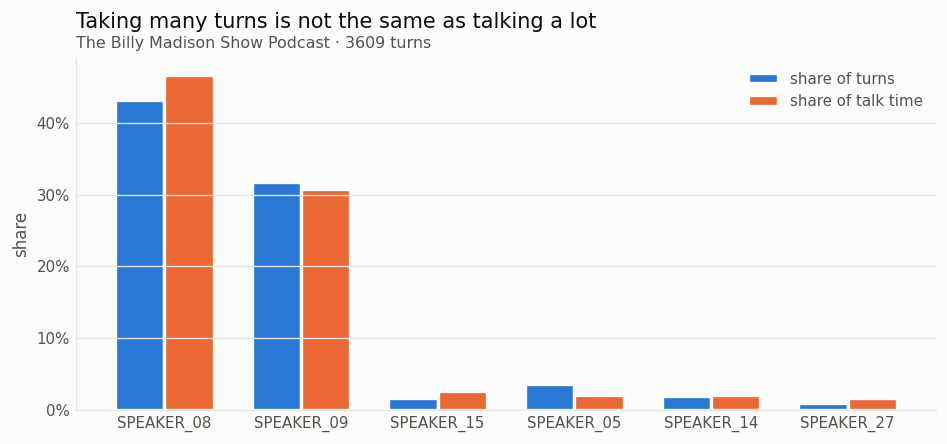

In [5]:
import matplotlib.pyplot as plt
import numpy as np

speakers = sorted(by_time, key=by_time.get, reverse=True)[:6]
x = np.arange(len(speakers))
share_turns = [by_turns[s]/sum(by_turns.values()) for s in speakers]
share_time = [by_time[s]/sum(by_time.values()) for s in speakers]

fig, ax = plt.subplots(figsize=(8, 3.8))
w = 0.36
ax.bar(x - w/2, share_turns, width=w, color=PALETTE[0], label="share of turns",
       edgecolor="#fcfcfb", linewidth=2)
ax.bar(x + w/2, share_time, width=w, color=PALETTE[5], label="share of talk time",
       edgecolor="#fcfcfb", linewidth=2)
ax.set_xticks(x); ax.set_xticklabels(speakers)
ax.yaxis.set_major_formatter(lambda v, p: f"{v:.0%}")
ax.legend(loc="upper right")
finish(ax, title="Taking many turns is not the same as talking a lot",
       subtitle=f"{ep.podcast_title[:44]} · {len(turns)} turns",
       ylabel="share")
plt.show()


## 8.3 Gaps and overlap

The gap between one turn ending and the next beginning is the pulse of a
conversation. Negative gaps are **overlap** — two people talking at once, which
diarization does record.


transitions        : 3608
overlapping        : 0 (0.0%)
median gap         : 0.00s
median overlap     : 0.00s


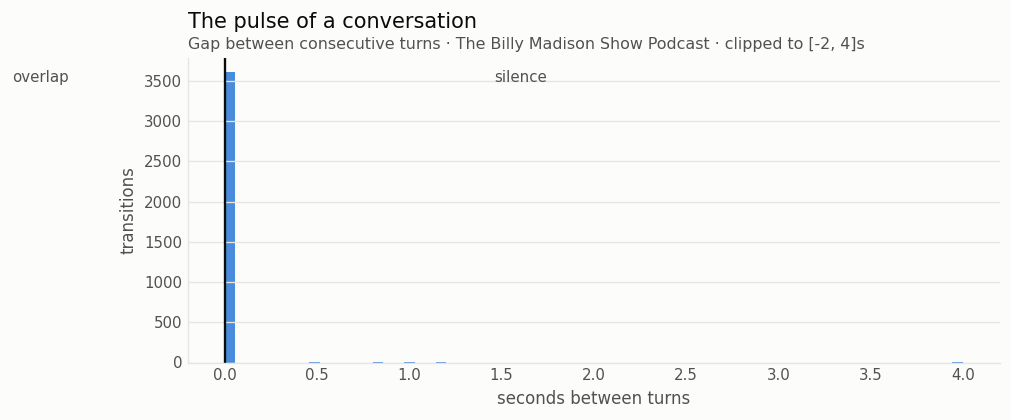

In [6]:
gaps = []
for a, b in zip(turns, turns[1:]):
    gaps.append(b.start_time - a.end_time)
gaps = np.array(gaps)

overlap = gaps[gaps < 0]
silence = gaps[gaps >= 0]
print(f"transitions        : {len(gaps)}")
print(f"overlapping        : {len(overlap)} ({len(overlap)/len(gaps):.1%})")
print(f"median gap         : {np.median(silence):.2f}s")
print(f"median overlap     : {abs(np.median(overlap)) if len(overlap) else 0:.2f}s")

fig, ax = plt.subplots(figsize=(8.5, 3.6))
clipped = np.clip(gaps, -2, 4)
ax.hist(clipped, bins=70, color=PALETTE[0], alpha=0.85)
ax.axvline(0, color=INK, linewidth=1.4)
ax.annotate("overlap", xy=(-1.0, 0.92), xycoords=("data", "axes fraction"),
            fontsize=9, color=INK_SECONDARY, ha="center")
ax.annotate("silence", xy=(1.6, 0.92), xycoords=("data", "axes fraction"),
            fontsize=9, color=INK_SECONDARY, ha="center")
finish(ax, title="The pulse of a conversation",
       subtitle=f"Gap between consecutive turns · {ep.podcast_title[:40]} · clipped to [-2, 4]s",
       xlabel="seconds between turns", ylabel="transitions")
plt.show()


## 8.4 The shape of an episode

`sliding_window_by_time()` chunks an episode by wall-clock time, which is the
natural unit for asking how something drifts: does the pace pick up? Does one
speaker take over in the second half?


windows: 86  (3 min wide, 1 min overlap)


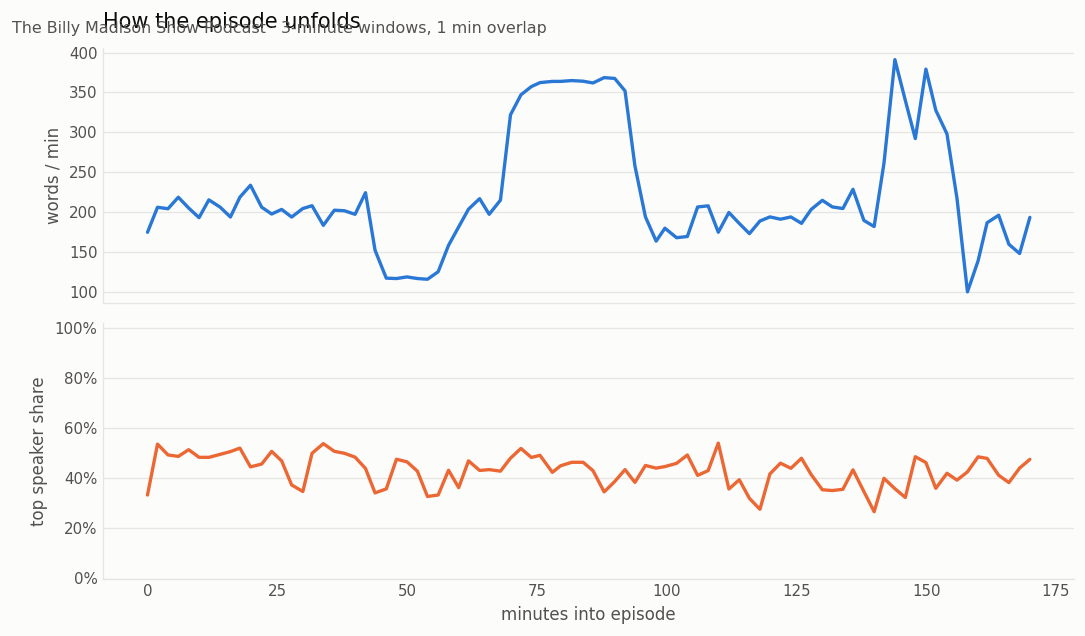

In [7]:
rows = []
for win in ep.sliding_window_by_time(window_duration=180, overlap_duration=60):
    if not win.turns:
        continue
    t0, t1 = win.time_range
    words = sum(t.word_count for t in win.turns)
    span = max(t1 - t0, 1e-6)
    dist = win.get_speaker_distribution()
    top = max(dist.values()) / sum(dist.values()) if dist else np.nan
    rows.append({"minute": t0 / 60, "words_per_min": words / (span / 60),
                 "turns": len(win.turns), "dominance": top})

w = pd.DataFrame(rows)
print(f"windows: {len(w)}  (3 min wide, 1 min overlap)")

fig, axes = plt.subplots(2, 1, figsize=(9, 5.4), sharex=True)
axes[0].plot(w.minute, w.words_per_min, color=PALETTE[0], linewidth=2)
axes[0].set_ylabel("words / min")
axes[0].set_title("How the episode unfolds", loc="left", pad=12)
axes[1].plot(w.minute, w.dominance, color=PALETTE[5], linewidth=2)
axes[1].set_ylabel("top speaker share")
axes[1].set_xlabel("minutes into episode")
axes[1].yaxis.set_major_formatter(lambda v, p: f"{v:.0%}")
axes[1].set_ylim(0, 1.02)
for a in axes:
    a.spines["top"].set_visible(False); a.spines["right"].set_visible(False)
fig.text(0.0, 0.94, f"{ep.podcast_title[:50]} · 3-minute windows, 1 min overlap",
         fontsize=9.5, color=INK_SECONDARY)
fig.tight_layout()
plt.show()


## 8.5 Across many episodes

One episode is an anecdote. The precomputed metrics let us look at the
distribution over hundreds without loading a single partition.


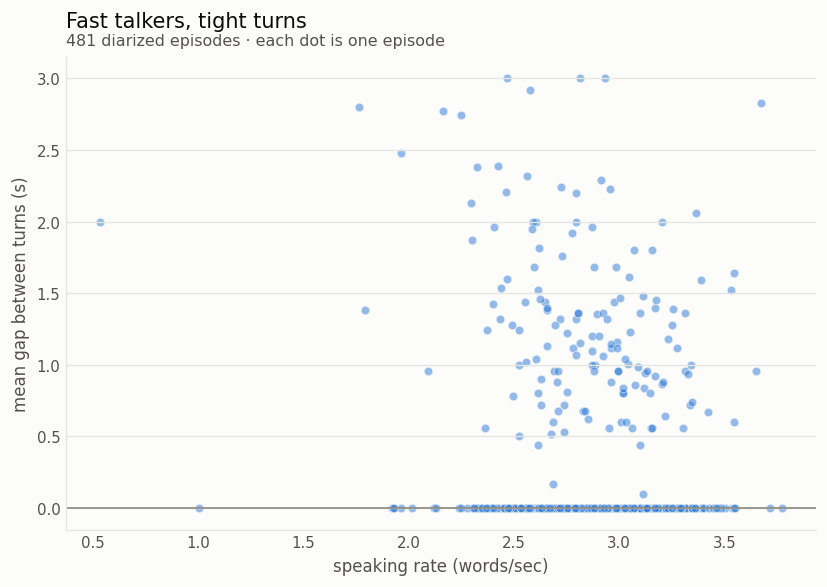

correlation: r = -0.12


In [8]:
if hits:
    m = pd.DataFrame(hits)
    if {"avg_words_per_second", "avg_gap_duration"} <= set(m.columns):
        d = m[(m.avg_words_per_second.between(0.5, 6)) &
              (m.avg_gap_duration.between(-1, 3))]
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(d.avg_words_per_second, d.avg_gap_duration, s=26,
                   color=PALETTE[0], alpha=0.5, edgecolor="#fcfcfb",
                   linewidth=0.6)
        ax.axhline(0, color=INK_MUTED, linewidth=1)
        finish(ax, title="Fast talkers, tight turns",
               subtitle=f"{len(d)} diarized episodes · each dot is one episode",
               xlabel="speaking rate (words/sec)",
               ylabel="mean gap between turns (s)")
        plt.show()
        print(f"correlation: r = {d.avg_words_per_second.corr(d.avg_gap_duration):+.2f}")


## 8.6 Caveats

* **Turn boundaries are diarization output.** A missed speaker change merges two
  turns into one; a spurious one splits a turn. Gap statistics inherit those
  errors, and short gaps are the most affected.
* **Overlap is under-detected.** Diarizers are conservative about simultaneous
  speech, so the overlap rate here is a floor.
* **Speaker labels are per-episode.** `SPEAKER_00` in two episodes is two
  different people. Never aggregate raw labels across episodes.
* **`unique_speaker_count` is broken** in `episode_metrics` (see above); use
  `num_main_speakers`.
* **Music and ads count as talk.** Nothing here distinguishes a read
  advertisement from conversation.
